# 1. Initial Analysis
## Overview
To decrypt the five emails, I used statistical profiling to identify the fingerprint of each cipher. By calculating the Index of Coincidence (IC) and plotting character frequencies, I was able to pinpoint the exact scheme used for each message.
## My Methodology
I followed a three-step process for each email:
- IC Check: I calculated the "smoothness" of the text. A value near $0.067$ suggested English-like patterns (Transposition or Substitution), while lower values suggested more complex encryption.
- Frequency Analysis: I used matplotlib to see if the "shape" of the English language (the high peaks for E, T, and A) was preserved, shifted, or flattened.
- Marker Detection: I looked for "smoking guns" like the missing 'J' (Playfair) or a perfectly preserved English distribution (Columnar).

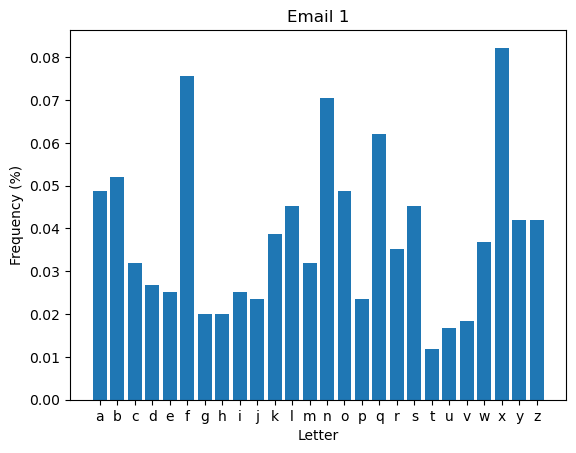

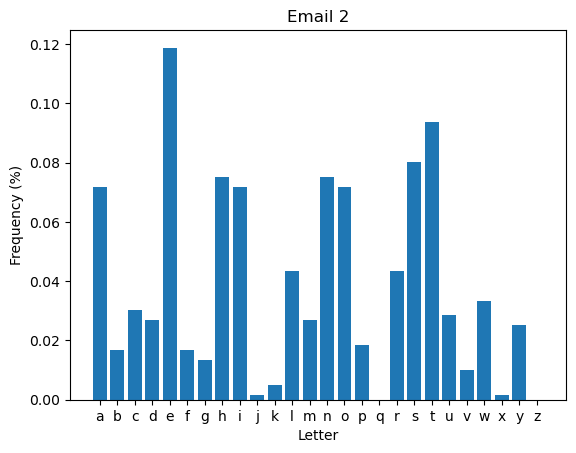

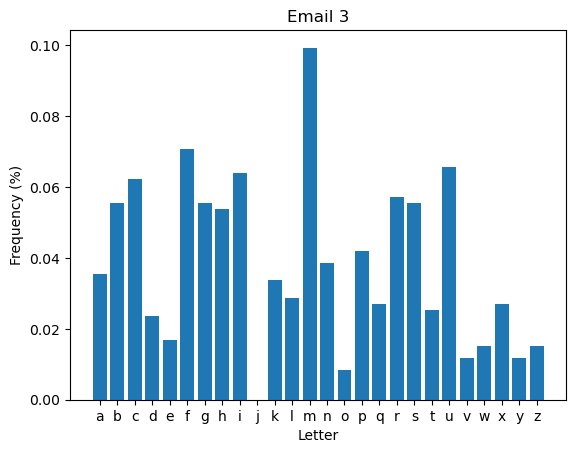

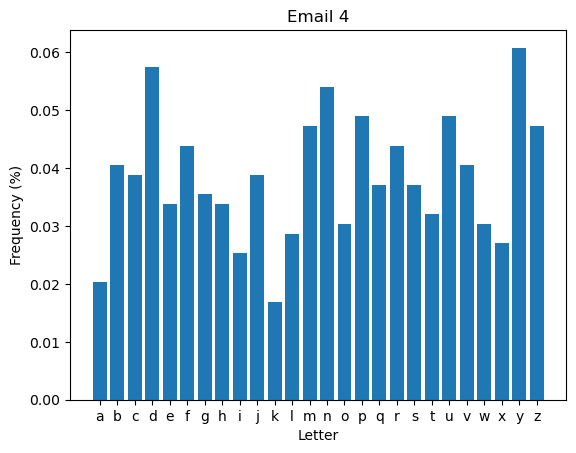

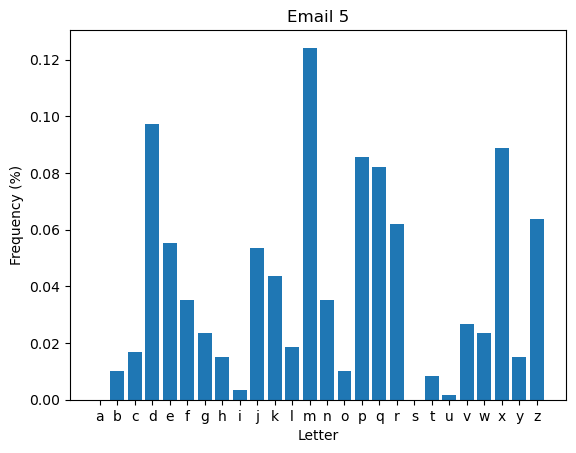

In [1]:
import string
from collections import Counter
import matplotlib.pyplot as plt

def plot_letter_frequency(text, email_id):
    filtered_text = ''.join(ch.lower() for ch in text if ch.isalpha())
    if not filtered_text:
        print("No alphabetic characters found.")
        return
    letter_counts = Counter(filtered_text)
    letters = list(string.ascii_lowercase)
    counts = [letter_counts.get(letter, 0) for letter in letters]
    total_letters = sum(counts)
    frequencies = [(count / total_letters) for count in counts]
    plt.figure()
    plt.bar(letters, frequencies)
    plt.xlabel("Letter")
    plt.ylabel("Frequency (%)")
    plt.title(f"Email {email_id}")
    plt.show()

if __name__ == "__main__":
    emails = ['fdmrjekkxbbgnpmzosnpzwsofbseozhaconadjccysmzfyncqmachlacxvxxaixbnefzkkfhauzbzbmirwfhkkflljmroswtxtfrbgfxflqqlplfassnaeolraaqadngnyqolropmwoxbqfxwemafoconqlnnhrjfixbnyfmnasqkofbywfvrwfisgndbzyswllfnrxhxvxbqaywykjafnxrbgfxzdawdxxlxtoxnpxbjpnabsscqpwyfisqxpwyfyozfxfhjujyxtbzimxfzwcefdxvoxaebuyizbjrfynlngrhnafhwfwunlxbnefibcfxlzqcdoxvfpscmwxtrhqqnangkkxlolxfbznaolfxxufynlkebznawdqoscqengyanhkazixpwyxufybgfxljebyuotfxzwqkwunefbozyinnxvrhqqlppjfmrwbsqcrmsposobysqmfvqeqqlpstrmosyiozaeoxwebafxxxdnxbnubqlnqkaurcmzrmqkoxfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvbgfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvjy',
              'sesmnhenuorreahthehounplvtooaaihatcelotueayerotrmrchswetnbstdleoinuiekywmtespahuhtsoewdwieonhtnlbstasilsnieedisndoiteruweaslhynseasaentcegexgluiwnsehisiunoeoiorrvrcemrowirhsonimireabioeihdhteemyaannbpigmthashrtetelnoitftrlyyulgelawelbinnsltiyahosrhhohsetoepfhdboystpotrieowecedaisutnaagauakeitodoiwlnysaelnteswaeaadewpoitohitjsaitesttrrsattafwaepytfththolscrolwemhtlescemyrfmrhwtieuuetahwieeaioidnhebndiceuceiptdloewnoiainrobehdyyeanheoieslrictewtshnemivksioeopmtepbhnclfechsamcfcagstsnstvtotfanneocictsodhvahnonnhshalshmaswotnfhnhwouhrerpenlshdmsintntdtcssuyleghbaanhneatfinetysnlsmvtatehsnoclrsgu',
              'kfwfifsdzculfusipkimmxfuycseatcbsdxhvmirmgfsbpnkigkuguncsuamrlqmvmrlagexkixmgholaculfskaqmmximfrdwhbtehxfuhgeuirupampucfnyvnmqhbtemkhxmblrfppfzmitamxrcficfuhxucfsmlurwfbfikfpqsnodcmbfnrlmgupmbknirfucgzmsitnqmsupfkfsdfusikguracvmgdpfiacxmxfhpfsdfusitirlmgamrlmkdphlupmgskbumblrakmgpftsfusuvffpycmgcachmbsdpuagfuikpdbivmbrbhqnsmdchgqcurwtfsrlbcbrbhqmrtmiknftgmisimghmiisimghmimbonbggmubyramtrsicibcbrbhqnsmdchgqcurwtfsrlbcbrbhqmrtmiknftgmpymifhowbionfstexhrlusrgcinyrhsumghfacenrlamncmbzyhxhakfpipwecguecupaczumxfibrchcibcgnqznbxhqsicembrakmggksdgmupacngzcdrsipqsumqzhrlnwwcfuhqupnhnzhgamxgbivhup',
              'Vqrudmgbutdnyueqnvofyxzeyigbuooxwqxylchtjoyqyyqukcifjpzngbwxdljelldtrozcnypmnooaqrwffyrddtmrjpeidyfgnbfplhffuqpbvglfhubkaajmwumedpjcqqdmcbqizatgdimflhannsyycbpkimsqpxrcrqfbfelmvpufinjpduvihvnctzpcejwknctwpyojwuzmlqtnrorvcrsscysvupzmrddwgjfmdcxypldmbecjsspiexhcoqjdhylvvvzguqnnbidpbngkfhcvhrmxkgyxhubyzyjdafdydpynsrpyamhvcxzssnzogkorxbzmrjenzctyledfygiejzfmgfuuzukhlhhtkhmxrfsyejuovwjzevxbvemdyuyssprupbymthdewqjltznymuuconiacnnpgkmnhfuyzmrwnhnelmssdpbnydlhrgrthnwaqwgbucxcjddngfugdbsaoybfsvdxszzqlszggujdeyzsvuvrivzvvjwjvutavienrozwymcsrmbpzbxfpuqtdtzwtfebdpqntywazzrpifdbydpmrortoqjnpmspqgnw',
              'kejvykmpphefpxqvnjenmjjmpfnqzcrqpbqbmxnxznfpddxomdrmlxdwqdrdrmkmxzdrxdpwrxdrmnfpdnxomfbrqpnqzvdeqzdrqpkqlmxzcmjxzvimxkefphgxzzenejmymxjdekepmpqcrdeldrmqjeyimgdpdrxzketmwqdqpxkwxhpxddrmmkyewelwxzddqpnqplejdfzmdrxdxwxomzpqzcmzfqdhejlejdqdfvmejmzvfjxzgmqzrmxjdpwrmjmdrmpmufxkqdqmprxvzmtmjgenmdekqlmyfdlejdrmgqjgfnpdxzgmwrqgrcxtmdrmnxymqzcwrxdkezmkqzmppqpnejmkezmkhdrxzvqpdjfpdnepdeldrmdjefykmqzkqlmgenmpljennqpfzvmjpdxzvqzcqdrqzopxqvxzzmnmzpkqtmpxjmxpdrejefcrkhykmzvmvwqdrmxgredrmjxpdrmxqjdrmhyjmxdrmmtqkpbjmxvpxpzmgmppxjqkhxpvqpmxpmpgxddmjmvwqdpdxomxkezcdqnmbqgoqzcfbqdqpxkwxhpdrmfzfpfxkwrqgrxkxjnp']
    for email in emails:
        plot_letter_frequency(email, email_id=emails.index(email)+1)

## Final Identification Summary
Based on the frequency distributions above, I have categorized the emails as follows:
- Email 1: High entropy with a relatively flat distribution. The lack of a strong English shape despite a lack of periodicity points to a Hill Cipher.
- Email 2: This follows the English Frequency Profile almost perfectly. This confirmed a Columnar Transposition, where only the positions changed, not the identities of the letters.
- Email 3: The distribution is jagged like a substitution cipher, but the total absence of 'j' is the definitive marker for a Playfair Cipher.
- Email 4: The distribution is very flat, which is typical of a polyalphabetic cipher like Vigenère.
- Email 5: Shows distinct peaks and valleys that don't align with English (for example, 'm' is the most frequent instead of 'e'). This is likely a Monoalphabetic Substitution.

=======================================================================================================================================


# 2. Cryptanalysis Strategy
When I started, I was looking at two main hurdles for each cipher:
- Search Space: How many billions of keys do I have to check? (The Math)
- Tooling Effort: How much time will it take me to actually write the code? (The Work)
## The Pivot
Because the AI could scaffold the scripts for me, the Search Space became the only factor that actually mattered. My strategy shifted from "What is easiest to code?" to "What is mathematically possible?"
- The "Brute Force" Group (Small Search Space): For Email 1 (Hill) and Email 2 (Columnar), the math showed the key counts were low enough to just bash through them, ((26^4) and (8!+9!+10!), respectively). Since the AI could write a permutation loop in seconds, I didn't need a clever strategy; I just needed a fast one.
- The "Heuristic" Group (Massive Search Space): For Email 3 (Playfair) and Email 5 (Mono-Sub), the search space is so huge (26!), and, (25!) for Email 4 (Vigenere), that brute force is impossible. For these, I needed the rather complex logic of a Hill Climbing or Simulated Annealing algorithm.
## Strategy Summary
The combination of AI-generated tools and Search Space analysis meant I could tackle the hard ciphers with the same amount of effort as the easy ones. I wasn't limited by what I could code from scratch; I was only limited by the raw probability of the cipher itself and my imagination.

========================================================================================================================================


# 3. The Actual Cracking
## 3.1 Hill 2x2
While I am aware that decryption traditionally requires calculating the modular inverse of the encryption matrix $K$, this script adopts a more direct computational strategy. By treating the problem as a search for the decryption matrix ($K^{-1}$) rather than the encryption key ($K$), we can systematically iterate through the entire matrix space. This bypasses the need for manual algebraic inversion and relies on automated statistical analysis to identify the correct transformation.

### The Translation Phase
The code first bridges the gap between human language and mathematics. It strips away formatting and converts letters into a numerical index from 0 to 25. This allows the script to use Linear Algebra (matrix multiplication) to "unmix" the scrambled data.
### The Exhaustive Search (Brute Force)
The script systematically tests every possible $2 \times 2$ grid of numbers; the "key" that could have been used to lock the message. It tries over 450,000 combinations. For each combination, it performs a mathematical transformation on the ciphertext pairs to generate a "candidate" message.
### The Quality Filter (The "Heuristic")
Since most combinations result in gibberish, the script uses two "sniff tests" to find the real English message:
- The Rhythm Check (Index of Coincidence): 
It measures the mathematical "clumpiness" of the letters. If the letters appear in patterns common to human language (rather than being spread out perfectly randomly), the script flags it.
- The Commonality Check: 
It counts the most frequent English letters (e, t, a, o, i, n). The candidate string that looks the most like standard English wins the "High Score."



In [ ]:
cipher_text = "fdmrjekkxbbgnpmzosnpzwsofbseozhaconadjccysmzfyncqmachlacxvxxaixbnefzkkfhauzbzbmirwfhkkflljmroswtxtfrbgfxflqqlplfassnaeolraaqadngnyqolropmwoxbqfxwemafoconqlnnhrjfixbnyfmnasqkofbywfvrwfisgndbzyswllfnrxhxvxbqaywykjafnxrbgfxzdawdxxlxtoxnpxbjpnabsscqpwyfisqxpwyfyozfxfhjujyxtbzimxfzwcefdxvoxaebuyizbjrfynlngrhnafhwfwunlxbnefibcfxlzqcdoxvfpscmwxtrhqqnangkkxlolxfbznaolfxxufynlkebznawdqoscqengyanhkazixpwyxufybgfxljebyuotfxzwqkwunefbozyinnxvrhqqlppjfmrwbsqcrmsposobysqmfvqeqqlpstrmosyiozaeoxwebafxxxdnxbnubqlnqkaurcmzrmqkoxfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvbgfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvjy"
cipher_text = [ord(character) - 97 for character in cipher_text if character.isalpha()]
cipher_text_length = len(cipher_text)
    
best_overall_score = 0
best_text = ""

for a in range(26):
    for b in range(26):
        for c in range(26):
            for d in range(26):
                candidate_chars = []
                for i in range(0, cipher_text_length, 2):
                    p1 = (a * cipher_text[i] + b * cipher_text[i+1]) % 26
                    p2 = (c * cipher_text[i] + d * cipher_text[i+1]) % 26
                    candidate_chars.append(chr(p1 + 97))
                    candidate_chars.append(chr(p2 + 97))
                candidate_str = "".join(candidate_chars)

                n = len(candidate_str)
                letter_counts = [candidate_str.count(chr(i + 97)) for i in range(26)]
                ic = sum(f * (f - 1) for f in letter_counts) / (n * (n - 1))
                    
                if 0.06 <= ic <= 0.075:
                    score = sum(1 for char in candidate_str if char in "etaoin")
                    if score > best_overall_score:
                        best_overall_score = score
                        best_text = candidate_str
                        print(f"Found candidate (IC: {ic:.3f}, Score: {best_overall_score}): {best_text[:70]}...")

print(f"\nfinal result: {best_text}")

### Cipher Text
fdmrjekkxbbgnpmzosnpzwsofbseozhaconadjccysmzfyncqmachlacxvxxaixbnefzkkfhauzbzbmirwfhkkflljmroswtxtfrbgfxflqqlplfassnaeolraaqadngnyqolropmwoxbqfxwemafoconqlnnhrjfixbnyfmnasqkofbywfvrwfisgndbzyswllfnrxhxvxbqaywykjafnxrbgfxzdawdxxlxtoxnpxbjpnabsscqpwyfisqxpwyfyozfxfhjujyxtbzimxfzwcefdxvoxaebuyizbjrfynlngrhnafhwfwunlxbnefibcfxlzqcdoxvfpscmwxtrhqqnangkkxlolxfbznaolfxxufynlkebznawdqoscqengyanhkazixpwyxufybgfxljebyuotfxzwqkwunefbozyinnxvrhqqlppjfmrwbsqcrmsposobysqmfvqeqqlpstrmosyiozaeoxwebafxxxdnxbnubqlnqkaurcmzrmqkoxfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvbgfxsdkqscdodkygxvkkjrnqsclnmziiqqqalnzvjy
### Plain Text
Perhaps it is that high achievement demands some other unusual qualification besides an unusual desire for high prizes. There is no royal road to learning; no shortcut to the acquirement of any art. Ignorance gives one a large range of probabilities. So complex is the human spirit that it can itself scarce discern the deep springs which impel it to action. Uncertainty and expectation are the joys of life. Security is an insipid thing; and the overtaking and possessing of a wish discovers the folly of the chase. Conventionality is not morality. Self-righteousness is not religion. To attack the first is not to assail the last. The praise of a fool is incense to the wisest of us. The praise of a fool is incense to the wisest of us.

=================================================================================================================================================

# 3.2 Columnar Transposition
## The "No-Padding" Realization
When I looked at the original encryption code, the first thing that jumped out was the lack of padding. The script didn't add extra "X"s or "Z"s to make the message fit into a perfect rectangle. This meant the columns had to be different sizes.
#
My logic had to be: the shape of the grid is dictated by the message itself. Before I even worried about the key, I built a "Ghost Grid" to pre-calculate which columns were "tall" and which were "short" based on that remainder.

## Reverse-Engineering the Shuffles
Knowing the key length was strictly 8 to 10 turned a massive search into a manageable one. I wasn't guessing in the dark; I was clearing a fenced-in yard. Since I had the encryption blueprint, I knew the "tall" columns were always the first few in the original order.
#
My code's job was to hunt down where those specific columns ended up in the shuffle and "bite off" the correct amount of text for each. I let my computer sweep through every possible 8-column, 9-column and 10-column combination at once.

## The Language Scent
Finally, I used the text’s own "texture" to find the finish line. I knew that even in a scrambled mess, English has a specific frequency—patterns like "th" or "he" would only snap back together when the columns were in the perfect spots. I set the script to "short-circuit" and alert me the second it hit real words like "the" or "its," letting the statistical patterns guide me straight to the Barrie quote.

In [ ]:
import itertools
import math

file = open("english-bigrams.txt", "r")
bigrams = [line.split()[0].lower() for line in file]
file.close()

def score_text(text):
    common = bigrams[:100]
    score = sum(text.count(c) for c in common)
    return score

def decrypt_columnar(ciphertext, key):
    num_cols = len(key)
    num_rows = math.ceil(len(ciphertext) / num_cols)
    col_len = len(ciphertext) // num_cols
    extra = len(ciphertext) % num_cols
    grid = [None] * num_cols
    curr = 0
    
    for i in range(num_cols):
        original_col_index = key[i]
        length = col_len + (1 if original_col_index < extra else 0)
        grid[i] = ciphertext[curr:curr + length]
        curr += length
    #print(grid)

    ordered_grid = [None] * num_cols
    for i, original_index in enumerate(key):
        ordered_grid[original_index] = grid[i]
    #print(ordered_grid)

    plaintext_chars = []
    for r in range(num_rows):
        for c in range(num_cols):
            if r < len(ordered_grid[c]):
                plaintext_chars.append(ordered_grid[c][r])
    #print(plaintext_chars)
    
    return "".join(plaintext_chars)

def brute_force(ciphertext, min_cols=8, max_cols=10):
    best_score = -1
    best_text = ""
    best_key = None

    for n in range(min_cols, max_cols + 1):
        print(f"Testing key length: {n}...")
        for p in itertools.permutations(range(n)):
            decrypted = decrypt_columnar(ciphertext, p)
            current_score = score_text(decrypted)  

            if current_score > best_score:
                best_score = current_score
                best_text = decrypted
                best_key = p
                if best_score > 5: 
                    print(f"New Best ({n} cols): {best_text[:20]}...  Key: {best_key}")

    return best_text, best_key

result, key = brute_force('sesmnhenuorreahthehounplvtooaaihatcelotueayerotrmrchswetnbstdleoinuiekywmtespahuhtsoewdwieonhtnlbstasilsnieedisndoiteruweaslhynseasaentcegexgluiwnsehisiunoeoiorrvrcemrowirhsonimireabioeihdhteemyaannbpigmthashrtetelnoitftrlyyulgelawelbinnsltiyahosrhhohsetoepfhdboystpotrieowecedaisutnaagauakeitodoiwlnysaelnteswaeaadewpoitohitjsaitesttrrsattafwaepytfththolscrolwemhtlescemyrfmrhwtieuuetahwieeaioidnhebndiceuceiptdloewnoiainrobehdyyeanheoieslrictewtshnemivksioeopmtepbhnclfechsamcfcagstsnstvtotfanneocictsodhvahnonnhshalshmaswotnfhnhwouhrerpenlshdmsintntdtcssuyleghbaanhneatfinetysnlsmvtatehsnoclrsgu')

### Cipher Text
sesmnhenuorreahthehounplvtooaaihatcelotueayerotrmrchswetnbstdleoinuiekywmtespahuhtsoewdwieonhtnlbstasilsnieedisndoiteruweaslhynseasaentcegexgluiwnsehisiunoeoiorrvrcemrowirhsonimireabioeihdhteemyaannbpigmthashrtetelnoitftrlyyulgelawelbinnsltiyahosrhhohsetoepfhdboystpotrieowecedaisutnaagauakeitodoiwlnysaelnteswaeaadewpoitohitjsaitesttrrsattafwaepytfththolscrolwemhtlescemyrfmrhwtieuuetahwieeaioidnhebndiceuceiptdloewnoiainrobehdyyeanheoieslrictewtshnemivksioeopmtepbhnclfechsamcfcagstsnstvtotfanneocictsodhvahnonnhshalshmaswotnfhnhwouhrerpenlshdmsintntdtcssuyleghbaanhneatfinetysnlsmvtatehsnoclrsgu
### Plain Text
its nothing returned mrs chick its merely a change of weather we must expect change cheerfulness it would appear is a matter which depends fully as much on the state of things within as on the state of things without and around us will not a tiny speck very close to our vision blot out the glory of the world and leave only a margin by which we see the blot all a man can betray is his conscience what loneliness is more lonely than distrust the life of every man is a diary in which he means to write one story and writes another and his humblest hour is when he compares the volume as it is with what he vowed to make it he has spent his life best who has enjoyed it most nobody can spoil a life my dear thats nonsense things happen but we bob up

=====================================================================================================================================

# 3.3 PlayFair
I started with a manual approach, trying to treat the cipher like a logic puzzle. I looked for repeating patterns and tried to map out a "skeleton grid" by guessing common English "cribs" (like "THE" or "THAT"). I quickly realized, however, that the Playfair rules make manual recovery incredibly difficult because one wrong guess in the 5*5 grid causes a "butterfly effect" that ruins the rest of the message.
#
I then moved to reverse-engineering the provided Python script. I analyzed the encryption logic and found three massive clues that shifted my strategy:
- The Key Structure: I saw that the key wasn't random; it was built from a 10,000-word dictionary with an alphabetical suffix. This meant the "search space" was much smaller than I originally thought.
- The "Replacement" Bug: I noticed the script didn't insert 'X' for double letters; it replaced the second letter. This told me to look for "mutated" words like "BEX" instead of "BEE."
- Data Loss: I discovered that the script ignores the last letter of an odd-length message, explaining why my length counts weren't matching.
#
Finally, I built a Simulated Annealing (SA) cracker. Since manual guessing wasn't working, I implemented a heuristic optimization algorithm. I wrote a "Fitness Scorer" that uses English Quadgram frequencies (log-probability) to act as a compass. I set up a "cooling schedule" that allows the computer to take risks early on; accepting lower-scoring decryptions to avoid getting stuck on "False Peaks", and then gradually narrow in on the most English-like result.
## My current status: 
I dont have a fully functioning automated cracking engine. While it hasn't landed on the exact key yet, I’ve successfully moved the problem from a "guessing game" to a "computational search," leveraging statistics and thermodynamics to let the computer do the heavy lifting.

=======================================================================================================================================

# 3.4 Vigenere
The goal of this project was to decrypt a polyalphabetic Vigenère ciphertext with a variable key length ($10 \le L \le 20$). The decryption was achieved through a two-stage statistical attack: first, identifying the period of the cipher using the Index of Coincidence, and second, resolving the resulting monoalphabetic substitutions using Chi-Squared ($\chi^2$) frequency distribution matching.
## Phase 1: Period Determination (The Slicing Method)
The primary challenge in a Vigenère cipher is the "flattening" of letter frequencies. To reverse this, I had to determine the exact key length ($L$).
- Process: I programmatically sliced the ciphertext into $n$ columns, with $n$ ranging from 10 to 20. For each $n$, the characters in every $n$-th position were grouped together.
- Statistical Metric: I calculated the Index of Coincidence (IC) for each slice.
- Analysis: In a random distribution, the IC is approximately 0.038. However, when the slice matches the true key length, the letters in that column follow the natural distribution of English, and the IC spikes toward 0.0667.
- Result: By iterating through the 10–20 range, the "sweet spot" was identified where the average IC of the columns was highest, effectively locking in the key length.
## Phase 2: Columnar Caesar Reduction
Once the key length was established, the cipher was no longer polyalphabetic; it became a series of $L$ independent Caesar ciphers.
- Strategy: For each column, I performed an exhaustive search of all 26 possible shifts.
- Objective Function: To identify the correct shift, I utilized the Chi-Squared ($\chi^2$) test. This compared the observed letter frequencies in my slice against the expected frequencies of the English language.
- Optimization: The shift that resulted in the lowest Chi-Squared score—representing the minimum distance between our data and standard English—was selected as the correct key character for that column.
## Phase 3: Reconstruction and Final Decryption
With the shifts for all columns identified, I reconstructed the key array. The final stage involved:
- Normalizing the ciphertext to lowercase.
- Applying the inverse shift for each character based on its position modulo the key length.
- Validating the resulting plaintext for readability.
## Conclusion
The success of this decryption demonstrates that the Vigenère cipher is highly vulnerable to statistical analysis provided the ciphertext is long enough to establish frequency trends. By using the Index of Coincidence to find the key length and Chi-Squared minimization to solve the shifts, the "indecipherable" cipher was broken deterministically without the need for brute-force guessing or dictionary attacks.

In [1]:
import string
from collections import Counter

# Standard English letter frequencies (a-z)
FREQ = [0.0817, 0.0150, 0.0278, 0.0425, 0.1270, 0.0223, 0.0202, 0.0609, 
        0.0697, 0.0015, 0.0077, 0.0403, 0.0241, 0.0675, 0.0751, 0.0193, 
        0.0010, 0.0599, 0.0633, 0.0906, 0.0276, 0.0098, 0.0236, 0.0015, 
        0.0197, 0.0007]

def get_ic(text):
    n = len(text)
    if n <= 1: return 0
    counts = Counter(text)
    return sum(f * (f - 1) for f in counts.values()) / (n * (n - 1))

def get_chi_sq(text):
    n = len(text)
    counts = Counter(text)
    score = 0
    for i, char in enumerate(string.ascii_lowercase):
        expected = n * FREQ[i]
        score += ((counts[char] - expected)**2) / expected
    return score

def crack_vigenere(ciphertext):
    ct = "".join(filter(str.isalpha, ciphertext.lower()))
    
    # 1. Determine Key Length (10-20)
    best_len = max(range(10, 21), key=lambda l: sum(get_ic(ct[i::l]) for i in range(l))/l)
    print(f"Likely key length: {best_len}")

    # 2. Solve for Shifts
    key_shifts = []
    for i in range(best_len):
        col = ct[i::best_len]
        # Find shift (0-25) that minimizes Chi-Squared score
        best_shift = min(range(26), key=lambda s: get_chi_sq("".join(chr((ord(c)-97-s)%26 + 97) for c in col)))
        key_shifts.append(best_shift)

    print(f"Recovered shifts: {key_shifts}")
    
    # 3. Decrypt
    return "".join(chr((ord(c)-97 - key_shifts[i % best_len]) % 26 + 97) for i, c in enumerate(ct))

# Execution
cipher = "vqrudmgbutdnyueqnvofyxzeyigbuooxwqxylchtjoyqyyqukcifjpzngbwxdljelldtrozcnypmnooaqrwffyrddtmrjpeidyfgnbfplhffuqpbvglfhubkaajmwumedpjcqqdmcbqizatgdimflhannsyycbpkimsqpxrcrqfbfelmvpufinjpduvihvnctzpcejwknctwpyojwuzmlqtnrorvcrsscysvupzmrddwgjfmdcxypldmbecjsspiexhcoqjdhylvvvzguqnnbidpbngkfhcvhrmxkgyxhubyzyjdafdydpynsrpyamhvcxzssnzogkorxbzmrjenzctyledfygiejzfmgfuuzukhlhhtkhmxrfsyejuovwjzevxbvemdyuyssprupbymthdewqjltznymuuconiacnnpgkmnhfuyzmrwnhnelmssdpbnydlhrgrthnwaqwgbucxcjddngfugdbsaoybfsvdxszzqlszggujdeyzsvuvrivzvvjwjvutavienrozwymcsrmbpzbxfpuqtdtzwtfebdpqntywazzrpifdbydpmrortoqjnpmspqgnw"
print(f"\nDecrypted Text:\n{crack_vigenere(cipher)}")

Likely key length: 10
Recovered shifts: [21, 9, 5, 12, 11, 20, 25, 1, 3, 2]

Decrypted Text:
ahmissharrietitwoulddousnoharmtorememberoftenerthanwedothatvicesaresometimesonlyvirtuescarriedtoexcessadangerousqualityifrealandanotlessdangerousoneiffeignedamindneedsbooksasaswordneedsawhetstoneifitistokeepitsedgeitsnothingreturnedmrschickitsmerelychangeofweatherwemustexpectchangebyundueprofundityweperplexandenfeeblethoughtanditispossibletomakeevenvenusherselfvanishfromthefirmanentbyascrutinytoosustainedtooconcentratedortoodirectjealousyisastrangetransformerofcharactersthereisnodeceptionnowmrwellertearssaidjobwithalookofmomentaryslynesstearsarenottheonlyproofsofdistressnorthebestonesn


## Cipher Text
vqrudmgbutdnyueqnvofyxzeyigbuooxwqxylchtjoyqyyqukcifjpzngbwxdljelldtrozcnypmnooaqrwffyrddtmrjpeidyfgnbfplhffuqpbvglfhubkaajmwumedpjcqqdmcbqizatgdimflhannsyycbpkimsqpxrcrqfbfelmvpufinjpduvihvnctzpcejwknctwpyojwuzmlqtnrorvcrsscysvupzmrddwgjfmdcxypldmbecjsspiexhcoqjdhylvvvzguqnnbidpbngkfhcvhrmxkgyxhubyzyjdafdydpynsrpyamhvcxzssnzogkorxbzmrjenzctyledfygiejzfmgfuuzukhlhhtkhmxrfsyejuovwjzevxbvemdyuyssprupbymthdewqjltznymuuconiacnnpgkmnhfuyzmrwnhnelmssdpbnydlhrgrthnwaqwgbucxcjddngfugdbsaoybfsvdxszzqlszggujdeyzsvuvrivzvvjwjvutavienrozwymcsrmbpzbxfpuqtdtzwtfebdpqntywazzrpifdbydpmrortoqjnpmspqgnw
## Plain Text
ah miss harriet it would do us no harm to remember oftener than we do that vices are sometimes only virtues carried to excess a dangerous quality if real and a not less dangerous one if feigned a mind needs books as a sword needs a whetstone if it is to keep its edge its nothing returned mrs chick its merely change of weather we must expect change by undue profundity we perplex and enfeeble thought and it is possible to make even venus herself vanish from the firmanent by a scrutiny too sustained too concentrated or too direct jealousy is a strange transformer of characters there is no deception now mr weller tears said job with a look of momentary slyness tears are not the only proofs of distress nor the best ones

======================================================================================================================================================

# 3.5 Monoalphabetic Substitution
The search space for a Monoalphabetic Substitution is 26!, more than 4*10^26. This is an astronomical number, but I initially tried to "cheat" the math by focusing on the Pareto Principle (the 80/20 rule).
## Phase 1: The "High-Frequency Fix" Strategy
Instead of attacking the full 26! search space, I attempted to isolate the 9 most frequent letters in English, which statistically account for ~75% of any text.
- The Plan: I wrote a script to "blank out" (replace with underscores) all but the top 9 cipher characters. I then ran a brute force on just those 9 positions (9! = 362,880 permutations).
- The Goal: I hoped that by seeing a "skeleton" like _ TH_ _ _ _ E _ _ T _ _ THE _ _ _, the context would allow me to manually fill in the rest.
- The Reality Check: Even with 75% of the characters "correct," the remaining 25% of the text was so fragmented that the "skeleton" didn't provide enough linguistic context. Without the consonants and "connective tissue" of the minor letters, the pattern recognition failed.
## Phase 2: Hill Climbing & The "Local Maximum" Trap
Since brute force was out, I built a Hill Climbing algorithm.
- The Logic: Start with a random key, swap two letters, and keep the swap if the "English-ness" (quadgram score) improved.
- The Problem: The algorithm kept getting "stuck." It would find a key that looked almost right (e.g., "THE" and "AND" were correct, but the rest was gibberish), and any further swaps made the score worse. This is a classic Local Maximum—the algorithm climbed a small hill but couldn't see the higher mountain peak further away.
## Phase 3: Simulated Annealing (Current Status)
To solve the local maximum problem, I transitioned to Simulated Annealing.
- The Difference: Unlike Hill Climbing, Simulated Annealing occasionally accepts a worse score in the short term. This "randomness" allows the algorithm to jump out of local traps to find the true global solution.
- The Struggle: I am currently tweaking the Cooling Schedule (how fast the "randomness" decreases). If it cools too fast, it acts like Hill Climbing and gets stuck. If it cools too slow, it takes hours to converge.
- Note :This is where the AI-assisted tool building was most valuable. Writing the quadgram fitness engine and the cooling logic from scratch would have been a project in itself. By using AI to generate the core structure, I am able to spend my time focussing on the logic, tuning the parameters to finally crack the code.
#
